In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle as pkl
import os

In [23]:
df_MZ = pd.read_csv('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/new_data_MZB.csv')

#Keep only the relevant columns
df = df_MZ[['Lamis ID', 'Age at BMT', 'Age at S1K', 'Days postBMT', 'percent_total_ki67+_T1_AA4.1+', 'percent_total_ki67+_T2', 'percent_total_ki67+_FM', 'percent_total_ki67+_T2_MZP', 'percent_total_ki67+_MZ']]
df = df.rename(columns={'percent_total_ki67+_T1_AA4.1+': 'Total_ki67_T1', 'percent_total_ki67+_T2': 'Total_ki67_T2', 'percent_total_ki67+_FM': 'Total_ki67_FM', 'percent_total_ki67+_T2_MZP': 'Total_ki67_T2MZP', 'percent_total_ki67+_MZ': 'Total_ki67_MZ'})
df = df.rename(columns={'Age at BMT': 'age_at_BMT', 'Age at S1K': 'age_at_S1K', 'Days postBMT': 'days_post_BMT', 'Lamis ID': 'ID'})

# Merge all Ki67 columns into one and create a cell_type column
cell_type_cols = ['Total_ki67_T1', 'Total_ki67_T2', 'Total_ki67_FM', 'Total_ki67_T2MZP', 'Total_ki67_MZ']
df_melted = df.melt(id_vars=['ID', 'age_at_BMT', 'age_at_S1K', 'days_post_BMT'], 
                     value_vars=cell_type_cols, 
                     var_name='cell_type', 
                     value_name='Total_ki67')

# Clean up cell_type names by removing 'Total_ki67_' prefix
df_melted['cell_type'] = df_melted['cell_type'].str.replace('Total_ki67_', '')

print(df_melted.head())
print(f"\nShape: {df_melted.shape}")

# Save the melted dataframe to a new CSV file
output_csv_path = '/Users/apoorvasingh/Desktop/MZB-new-analysis/data/TotalKi67.csv'
df_melted.to_csv(output_csv_path, index=False)
print(f"Melted dataframe saved to {output_csv_path}")

       ID  age_at_BMT  age_at_S1K  days_post_BMT cell_type  Total_ki67
0  832634          74          88             14        T1   98.878813
1  848687          41          88             14        T1   98.220367
2  832635          74          92             18        T1   99.561646
3  848686          41          59             18        T1   99.259821
4  832636          74          95             21        T1   98.216534

Shape: (110, 6)
Melted dataframe saved to /Users/apoorvasingh/Desktop/MZB-new-analysis/data/TotalKi67.csv


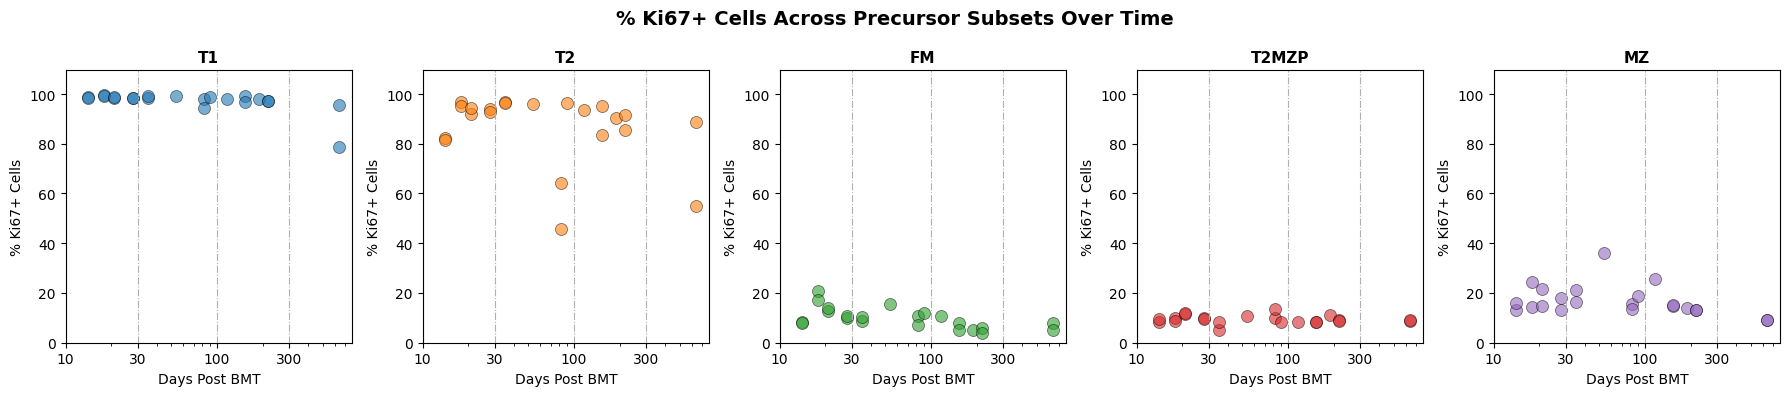

In [24]:
# Define the precursor subsets with their corresponding columns
precursors = {

 
    'T1': 'percent_total_ki67+_T1_AA4.1+',
    'T2': 'percent_total_ki67+_T2',
    'FM': 'percent_total_ki67+_FM',
    'T2MZP': 'percent_total_ki67+_T2_MZP',
    'MZ': 'percent_total_ki67+_MZ'
}

colors = {'T1': '#1f77b4', 'T2': '#ff7f0e', 'FM': '#2ca02c', 'T2MZP': '#d62728', 'MZ': '#9467bd'}

# Create faceted subplots
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
fig.suptitle('% Ki67+ Cells Across Precursor Subsets Over Time', fontsize=14, fontweight='bold')

for idx, (precursor, col) in enumerate(precursors.items()):
    ax = axes[idx]
    
    # Plot data
    ax.scatter(df_MZ['Days postBMT'], df_MZ[col], color=colors[precursor], 
               s=75, alpha=0.6, edgecolor='black', linewidth=0.5)
    
    # Formatting
    ax.set_xscale('log')
    ax.set_xticks([10, 30, 100, 300])
    ax.set_xticklabels([10, 30, 100, 300])
    ax.set_xlabel('Days Post BMT', fontsize=10)
    ax.set_ylabel('% Ki67+ Cells', fontsize=10)
    ax.set_title(precursor, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', linestyle='-.')
    ax.set_ylim(0, df_MZ[[col for col in precursors.values()]].max().max() * 1.1)

plt.tight_layout()
# plt.savefig('percent_ki67_precursors.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# load posterior draws from csv
# posterior = pd.read_csv('')

file_path = '/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_influx_T1_logit.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        df = pkl.load(f)
else:
    raise EOFError("File is empty")

posterior = df.draws_pd()

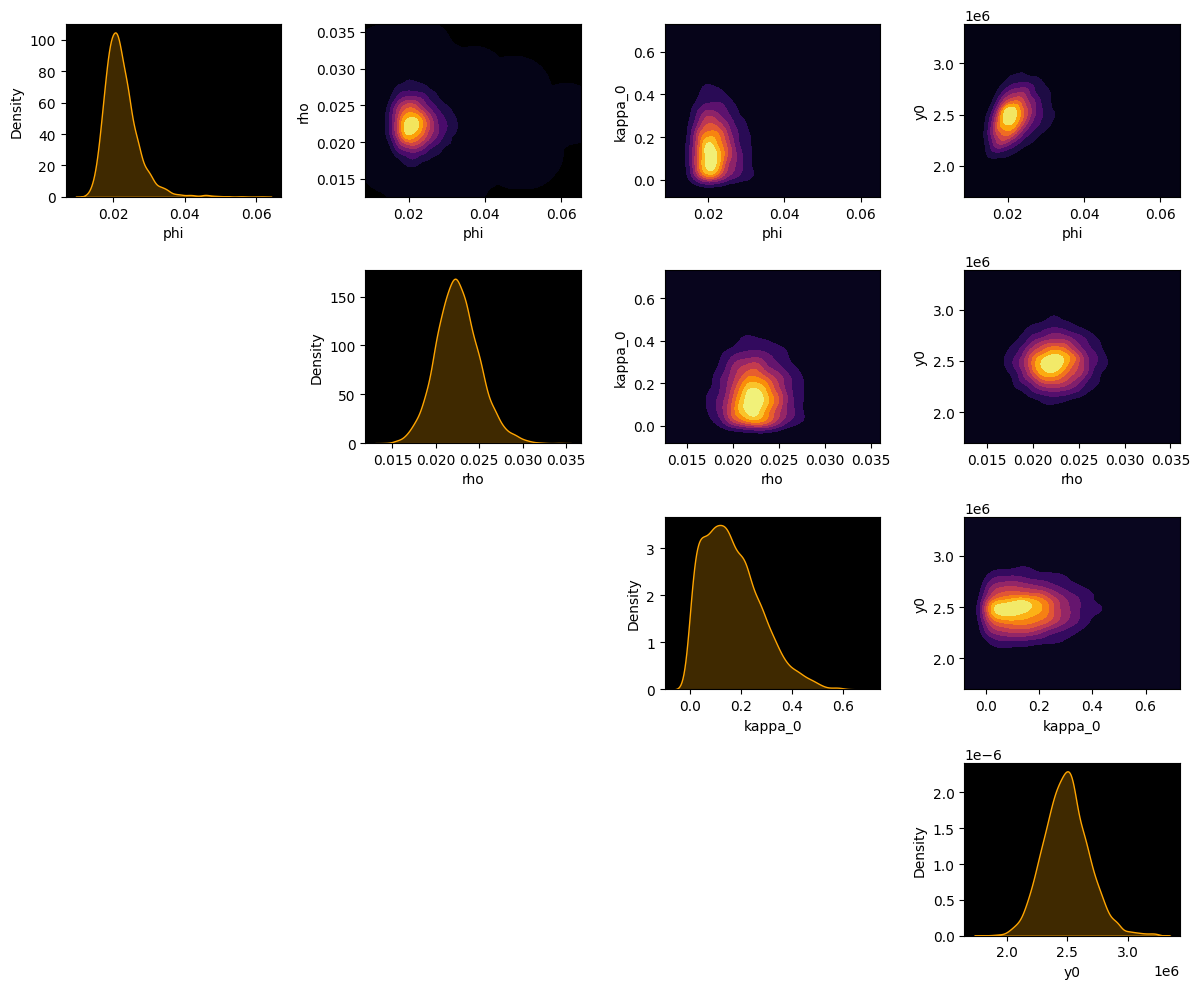

In [26]:
# parameter names based on the Stan model
param_names = ['phi', 'rho', 'kappa_0', 'y0']

# plot bivariate distribution for all parameters
fig, axes = plt.subplots(len(param_names), len(param_names), figsize=(12, 10))
for i in range(len(param_names)):
    for j in range(len(param_names)):
        axes[i, j].set_facecolor('black')  # Set axes background to black
        if i == j:
            sns.kdeplot(x=posterior[param_names[i]], ax=axes[i, j], fill=True, color='orange')
            axes[i, j].set_xlabel(param_names[i])
            axes[i, j].set_ylabel('Density')
        elif i < j:
            sns.kdeplot(x=posterior[param_names[i]], y=posterior[param_names[j]], fill=True, cmap='inferno', thresh=0, levels=10, ax=axes[i, j])
            axes[i, j].set_xlabel(param_names[i])
            axes[i, j].set_ylabel(param_names[j])
        else:
            axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [27]:
df. MZ_counts_pred1

array([[2459250., 2459250., 2459250., ..., 2459250., 2459250., 2459250.],
       [2531470., 2531470., 2531470., ..., 2531470., 2531470., 2531470.],
       [2666160., 2666160., 2666160., ..., 2666160., 2666160., 2666160.],
       ...,
       [2286280., 2286280., 2286280., ..., 2286280., 2286280., 2286280.],
       [2585130., 2585130., 2585130., ..., 2585130., 2585130., 2585130.],
       [2325560., 2325560., 2325560., ..., 2325560., 2325560., 2325560.]],
      shape=(5000, 698))

In [28]:
# Generate MZ_pred1 and total_Ki67_pred1 arrays from k_hat_pred1
MZ_pred1 = []
total_Ki67_pred1 = []
n_cols = df.k_hat_pred1.shape[1]
n_groups = n_cols // 4  # Number of complete groups of 4

for i in range(len(df.k_hat_pred1[:,0])):
    for j in range(n_groups):
        MZ_pred1.append(df.k_hat_pred1[i,4 * j] + df.k_hat_pred1[i,4 * j + 1] + df.k_hat_pred1[i,4 * j + 2] + df.k_hat_pred1[i,4 * j + 3])
        total_Ki67_pred1.append(df.k_hat_pred1[i,4 * j] + df.k_hat_pred1[i,4 * j + 2])
        

MZ_pred1_array= np.array(MZ_pred1).reshape(df.k_hat_pred1.shape[0], n_groups)
total_Ki67_pred1_array= np.array(total_Ki67_pred1).reshape(df.k_hat_pred1.shape[0], n_groups)
print(MZ_pred1_array)
print(total_Ki67_pred1_array.shape)

[[2459252.3929 2459248.916  2459253.7    ... 2459253.1    2459251.9
  2459251.7   ]
 [2531472.9836 2531476.981  2531468.76   ... 2531474.     2531472.
  2531472.    ]
 [2666164.3523 2666164.206  2666164.32   ... 2666162.9    2666166.2
  2666159.6   ]
 ...
 [2286274.051  2286278.471  2286276.15   ... 2286279.6    2286273.5
  2286277.4   ]
 [2585136.1897 2585136.875  2585130.29   ... 2585126.5    2585132.9
  2585128.3   ]
 [2325556.3382 2325552.438  2325559.52   ... 2325560.5    2325559.6
  2325558.8   ]]
(5000, 698)


In [29]:
print(total_Ki67_pred1_array)

# Calculate percentage of Ki67+ cells in MZ subset
percentage_Ki67_MZ = (total_Ki67_pred1_array / MZ_pred1_array) * 100
print(percentage_Ki67_MZ)

[[404573.211 405770.29  406605.86  ... 370385.1   370356.9   370328.7  ]
 [381828.719 381970.7   382074.08  ... 362494.    362471.    362448.   ]
 [359941.881 360061.04  360147.36  ... 335138.9   335111.2   335082.6  ]
 ...
 [369193.45  370981.56  372263.48  ... 370251.6   370244.5   370236.4  ]
 [427487.191 429530.92  430990.32  ... 425309.5   425296.9   425283.3  ]
 [379315.403 381051.64  382284.72  ... 360560.5   360533.6   360506.8  ]]
[[16.45106505 16.49976492 16.53370939 ... 15.06087763 15.05973829
  15.05859282]
 [15.08326265 15.08884745 15.09298025 ... 14.31948343 14.31858618
  14.31767762]
 [13.50036357 13.50483362 13.50807065 ... 12.5700834  12.56902889
  12.5679873 ]
 ...
 [16.14825877 16.22643806 16.28252475 ... 16.19450219 16.19423485
  16.19385294]
 [16.53635088 16.61540339 16.67189935 ... 16.45217362 16.45164548
  16.45114867]
 [16.31073807 16.38542455 16.43839759 ... 15.50424081 15.50309009
  15.50194302]]


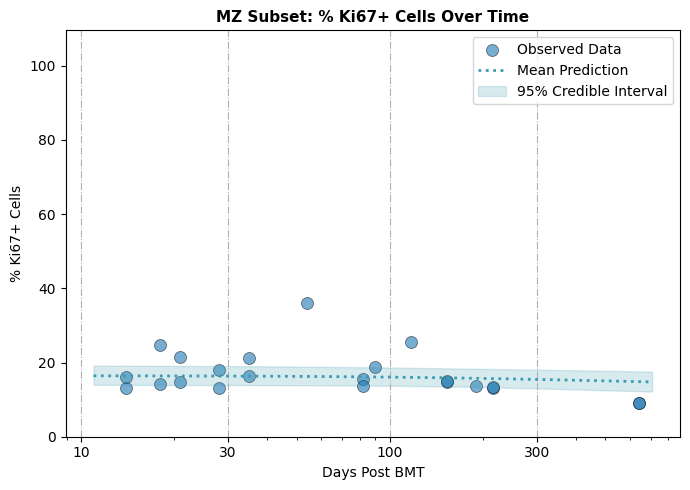

In [30]:
# Adjust time points to match prediction dimensions
ts1 = np.linspace(52, 750, percentage_Ki67_MZ.shape[1])
tb1 = np.arange(52, 750,1) - 41

fig, ax = plt.subplots(figsize=(7, 5))

# Plot observed data
ax.scatter(df_MZ['Days postBMT'], df_MZ['percent_total_ki67+_MZ'],  
               s=75, alpha=0.6, edgecolor='black', linewidth=0.5, label='Observed Data')

# Plot predictions
ax.plot(tb1, np.mean(percentage_Ki67_MZ, axis=0), color='#3b9bb3', linestyle='dotted', linewidth=2, label='Mean Prediction')
ax.fill_between(tb1, np.quantile(percentage_Ki67_MZ, 0.025, axis=0), np.quantile(percentage_Ki67_MZ, 0.975, axis=0), color='#3b9bb3', alpha=0.2, label='95% Credible Interval')
 
# Formatting
ax.set_xscale('log')
ax.set_xticks([10, 30, 100, 300])
ax.set_xticklabels([10, 30, 100, 300])
ax.set_xlabel('Days Post BMT', fontsize=10)
ax.set_ylabel('% Ki67+ Cells', fontsize=10)
ax.set_title('MZ Subset: % Ki67+ Cells Over Time', fontsize=11, fontweight='bold')
ax.grid(True, axis='x', linestyle='-.')
ax.legend()
ax.set_ylim(0, df_MZ[[col for col in precursors.values()]].max().max() * 1.1)

plt.tight_layout()
plt.show()